In [1]:
# Standard packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Model

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split, StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from catboost import CatBoostClassifier

# Pipeline + Transformer:

from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Neural network

import torch
from torch import nn
#import cudf

# Speed up options
#%load_ext cudf.pandas
#%load_ext cuml.accel



In [2]:
# Reading in data

train = pd.read_csv('train.csv')

test = pd.read_csv('test.csv')

orig = pd.read_csv('f1_strategy_dataset_v4.csv')

changes = pd.read_csv('changes_made.csv')

scores_df = pd.read_csv('scores_df.csv')

In [3]:
# Setting up target columns and test IDs

ytrain = train['PitNextLap']

yorig = orig['PitNextLap']

test_id = test['id']

In [4]:
# Removing ID column and target

Xtrain = train.drop(columns=['id','PitNextLap'], axis = 1).copy()

Xtest = test.drop(columns = ['id'], axis = 1).copy()

Xorig = orig.drop(columns= ['Normalized_TyreLife', 'PitNextLap'], axis = 1).copy()

# Data cleaning #

In [101]:


# Null values

Xtrain.info(), Xtest.info() , Xorig.info() # No null values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
dtypes: float64(6), int64

(None, None, None)

In [102]:
num_cols = Xtrain.select_dtypes(['int','float']).columns.to_list()
num_cols

['Year',
 'PitStop',
 'LapNumber',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change']

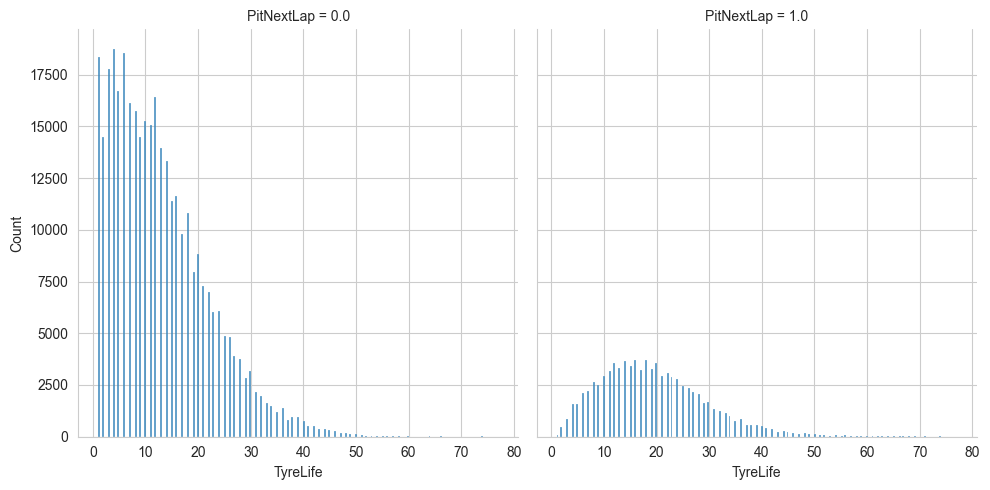

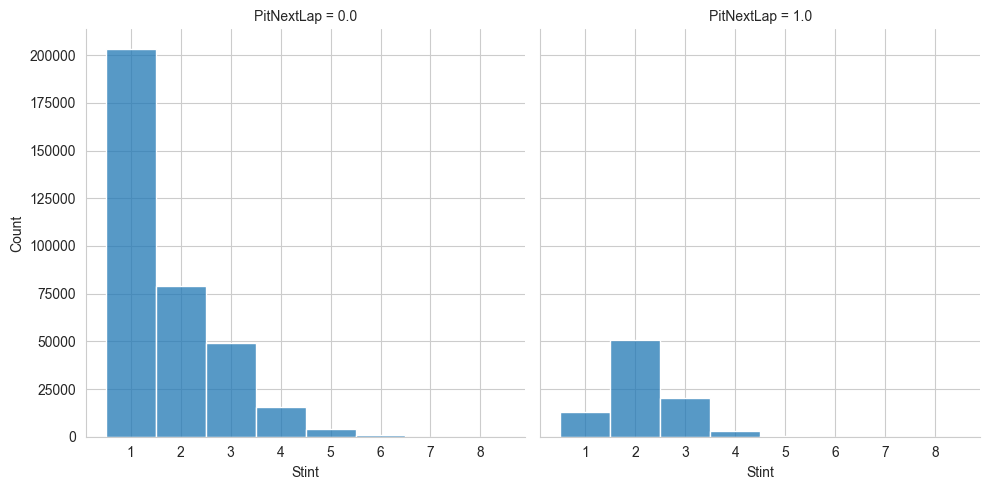

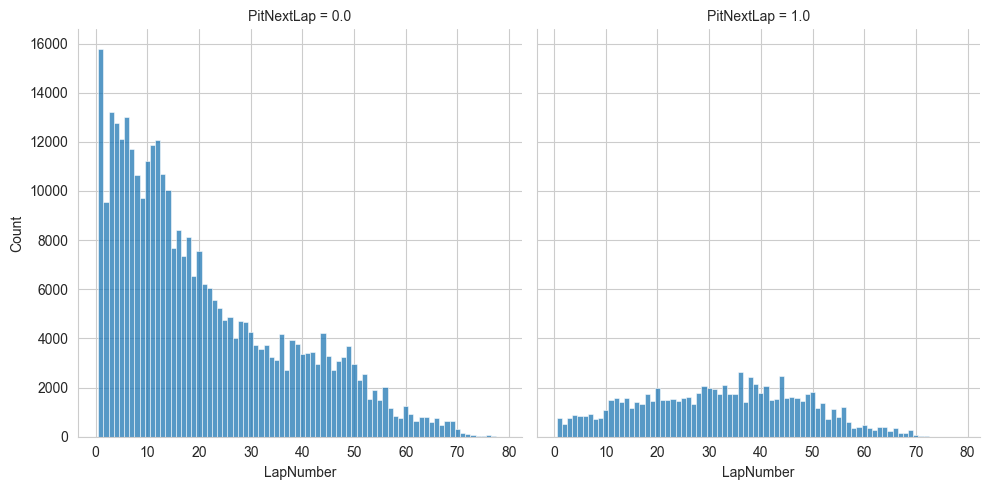

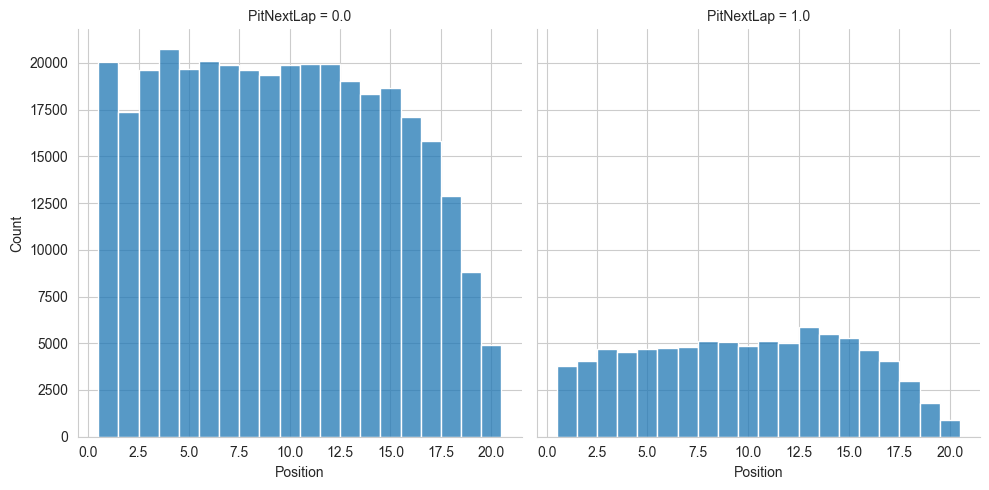

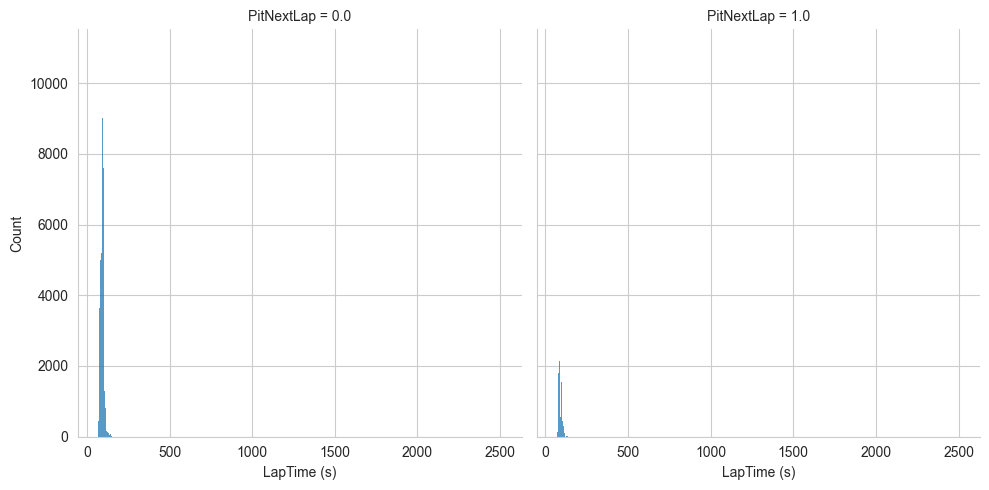

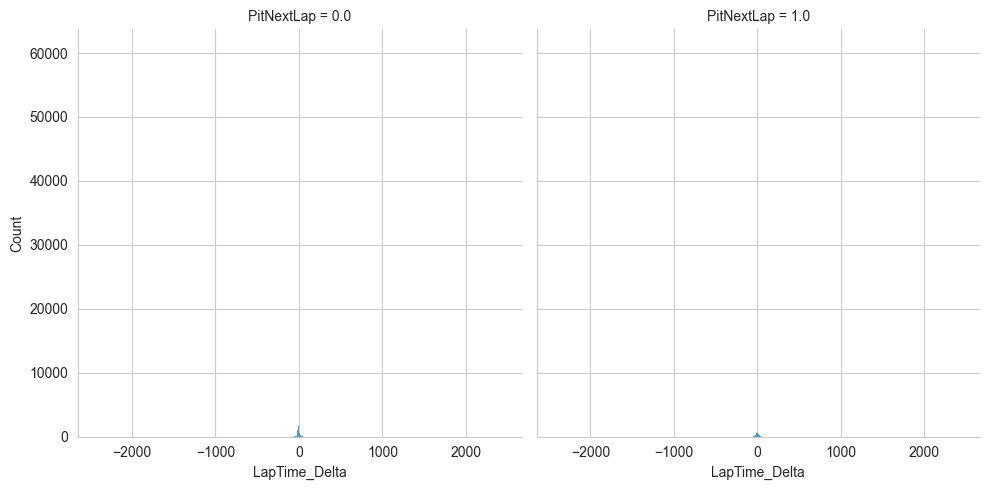

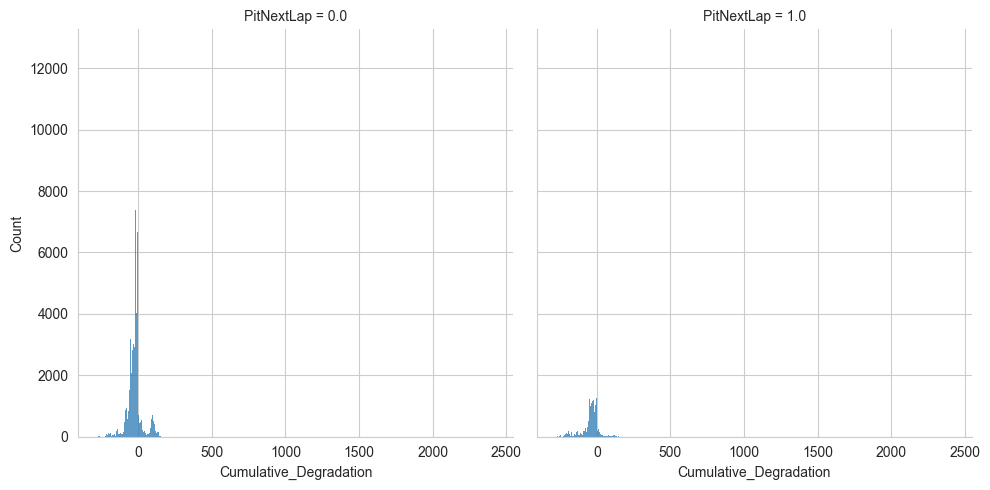

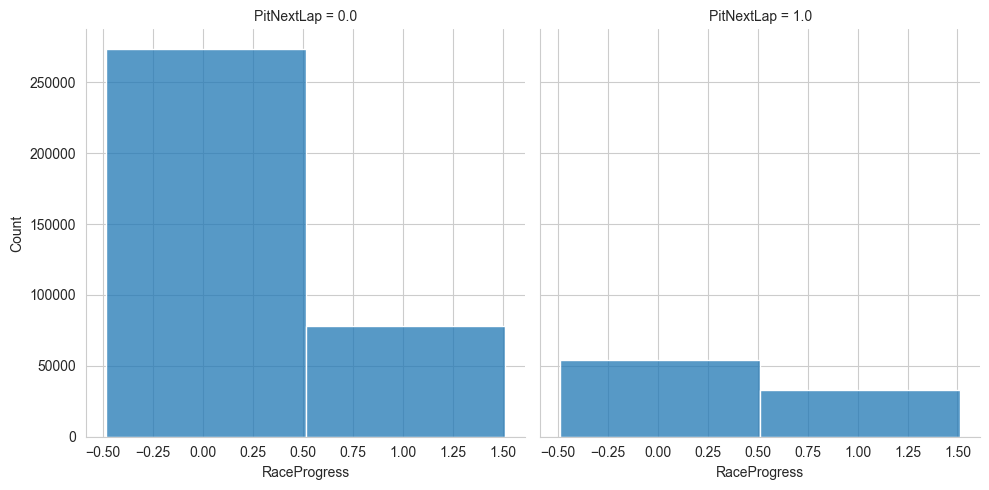

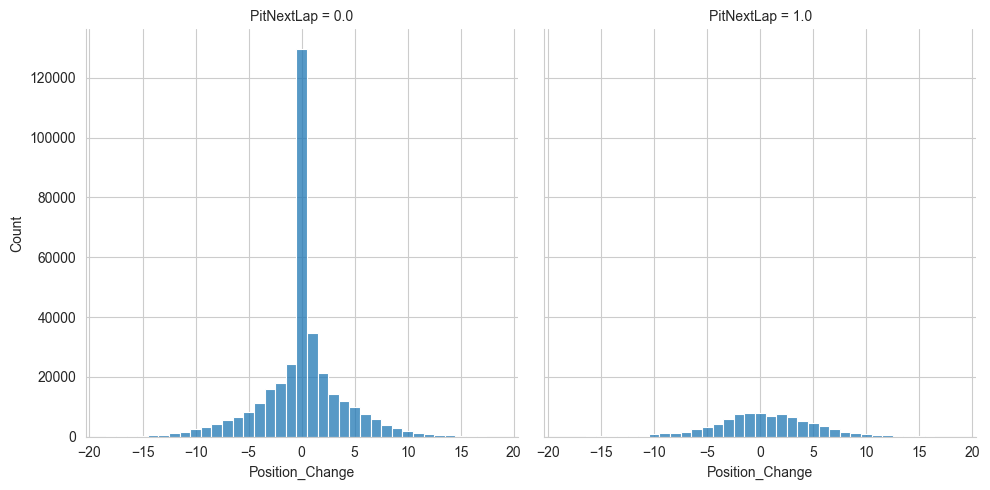

In [7]:
# Understanding if any feature outliers have a significant impact on target

sns.displot(
    data=train,
    x = 'TyreLife',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd'
)

sns.displot(
    data=train,
    x = 'Stint',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)

sns.displot(
    data=train,
    x = 'LapNumber',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)


sns.displot(
    data=train,
    x = 'Position',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)

sns.displot(
    data=train,
    x = 'LapTime (s)',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd'
)

sns.displot(
    data=train,
    x = 'LapTime_Delta',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd'
)


sns.displot(
    data=train,
    x = 'Cumulative_Degradation',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)

sns.displot(
    data=train,
    x = 'RaceProgress',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)

sns.displot(
    data=train,
    x = 'Position_Change',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)


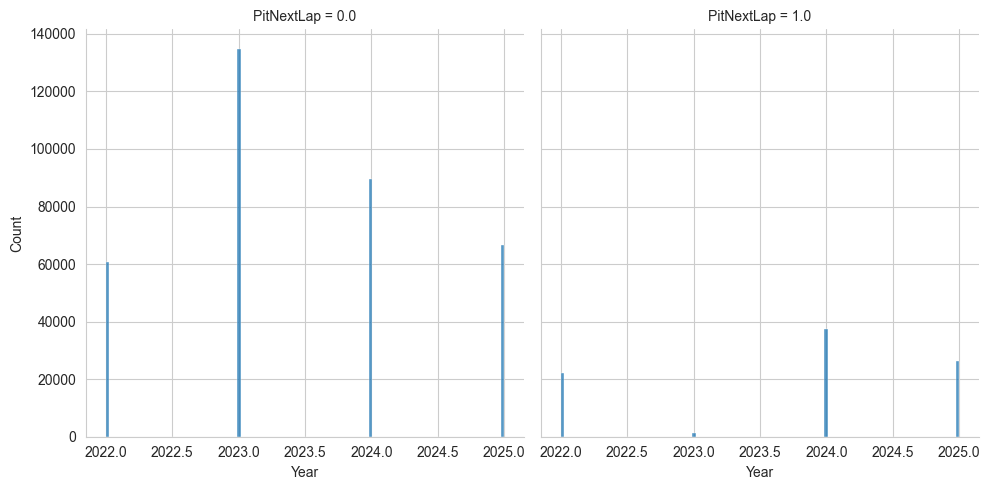

In [8]:
sns.displot(
    x = 'Year',
    data = train,
    col = 'PitNextLap'
)

In [9]:
# Summary statisitcs
Xtrain[num_cols].describe()


,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000


In [103]:
# Winsorization
cols_to_remove = ['PitStop','PitNextLap'] # Binary columns that contain imbalanced responses

def num_outliers(df, choice):

    """
    The function applies the moethod of winsorization to outliers. Choice is a boolean repsonse. True applies the method to the data
    frame. Fasle just prints out any information you would like to know about the data frame 
    """

    df_new = df.copy()

    num_cols = df_new.select_dtypes(['int','float']).columns.to_list()

    num_cols = list(set(num_cols) - set(cols_to_remove))

    df_new[num_cols] = df_new[num_cols].astype('float')

    for col in num_cols:

        q1 = np.quantile(df_new[col], 0.25)

        q3 = np.quantile(df_new[col], 0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr

        upper = q3 + 1.5 * iqr

        # Mask returns true/falses where data column meets outlier criteria

        mask = (df_new[col] < lower) | (df_new[col] > upper)

        low_mask = (df_new[col] < lower)

        high_mask = (df_new[col] > upper)

        n_outliers = mask.sum()

        print(f'{col} has {n_outliers} outliers')

        if choice == True: # Winsorization 

            df_no_outliers = df_new.loc[~mask]

            df_out_low = df_new.loc[low_mask]

            df_out_high = df_new.loc[high_mask]

            df_out_high.loc[:, col] = upper

            df_out_low.loc[:, col] = lower

            df_new = pd.concat([df_no_outliers, df_out_high, df_out_low], axis = 0).sort_index()
        else:
            print('No changes made to dataframe')



    print(f'Shape of new data frame {df_new.shape} | Shape of old data frame {df.shape}')


    return df_new



In [104]:
Xtrain_outliers = num_outliers(Xtrain, True)
print('//////////')
Xtest_outliers = num_outliers(Xtest, True)
print('//////////')
Xorig_outliers = num_outliers(Xorig, True)

LapNumber has 16 outliers
Position_Change has 61180 outliers
Cumulative_Degradation has 49869 outliers
LapTime_Delta has 58900 outliers
Year has 0 outliers
Position has 0 outliers
TyreLife has 5711 outliers
LapTime (s) has 5905 outliers
Stint has 24078 outliers
RaceProgress has 0 outliers
Shape of new data frame (439140, 14) | Shape of old data frame (439140, 14)
//////////
LapNumber has 4 outliers
Position_Change has 26289 outliers
Cumulative_Degradation has 21168 outliers
LapTime_Delta has 25068 outliers
Year has 0 outliers
Position has 0 outliers
TyreLife has 2494 outliers
LapTime (s) has 2531 outliers
Stint has 10266 outliers
RaceProgress has 0 outliers
Shape of new data frame (188165, 14) | Shape of old data frame (188165, 14)
//////////
LapNumber has 0 outliers
Position_Change has 5526 outliers
Cumulative_Degradation has 14813 outliers
LapTime_Delta has 11011 outliers
Position has 0 outliers
Year has 0 outliers
TyreLife has 2360 outliers
LapTime (s) has 2926 outliers
Stint has 59

In [105]:
# Seeing how the distribution of the numerical columns changes after function is applied
Xtrain_outliers[num_cols].describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105887,1.747386,14.064292,9.630339,90.694495,-3.198990,-25.770644,0.337661,0.179501
std,1.024930,0.342915,16.958189,0.842466,9.470867,5.278770,10.909845,9.245325,36.721484,0.253277,3.166100
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-22.382500,-107.117125,0.012821,-5.500000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000
max,2025.000000,1.000000,76.500000,3.500000,41.000000,20.000000,122.246000,13.613500,54.351875,1.000000,6.500000


In [106]:
Xtrain_outliers['Cat_Year'] = Xtrain_outliers.Year.astype('object')
Xtest_outliers['Cat_Year'] = Xtest_outliers.Year.astype('object')
Xorig_outliers['Cat_Year'] = Xorig_outliers.Year.astype('object')

In [107]:
cat_cols = Xtrain_outliers.select_dtypes('object').columns.to_list()
cat_cols

['Driver', 'Compound', 'Race', 'Cat_Year']

In [108]:
# Identifying any potential columns with categorical outliers or anomalies, mis-entries etc. and what columns to encode
Xtrain_outliers[cat_cols].describe()

,Driver,Compound,Race,Cat_Year
count,439140,439140,439140,439140.0
unique,887,5,26,4.0
top,MAS,MEDIUM,Dutch Grand Prix,2023.0
freq,1682,211141,24462,136147.0


In [109]:
# Categorical outliers

def cat_outliers(df):

    df_new = df.copy()

    for i in range(10):

        df_new['Driver'] = df_new['Driver'].apply(lambda x: f'D{i}00s' if x.startswith(f'D{i}') else x)


    print('All categorical outliers were removed')

    return df_new




In [110]:
Xtrain_cat_outliers = cat_outliers(Xtrain_outliers)
Xtest_cat_outliers = cat_outliers(Xtest_outliers)
Xorig_cat_outliers = cat_outliers(Xorig_outliers)

All categorical outliers were removed
All categorical outliers were removed
All categorical outliers were removed


# Feature engineering #

In [111]:
# Categorical feature engineering

def cat_fe(df):

    df_new = df.copy()

    for i, c1 in enumerate(cat_cols):
        for j, c2 in enumerate(cat_cols):
            if i < j:

                df_new[f'BI_Combin_{c1}_{c2}'] = df_new[c1].astype(str) + "_" + df_new[c2].astype(str)

    for i, c1 in enumerate(cat_cols):
        for j, c2 in enumerate(cat_cols):
            for k, c3 in enumerate(cat_cols):
                if i < j:
                    if j < k:

                        df_new[f'TRI_Combin_{c1}_{c2}_{c3}'] = df_new[c1].astype(str) + "_" + df_new[c2].astype(str) + "_" + df_new[c3].astype(str)
    

                
    print('Categorical Feature Engineering complete')

    return df_new


In [112]:
Xtrain_cat = cat_fe(Xtrain_cat_outliers)

Xtest_cat = cat_fe(Xtest_cat_outliers)

Xorig_cat = cat_fe(Xorig_cat_outliers)

Categorical Feature Engineering complete
Categorical Feature Engineering complete
Categorical Feature Engineering complete


In [113]:
# Numerical feature engineering

def num_fe(df):

    df_new = df.copy()

    df_new['Lap_x_Delta'] = df_new['LapTime (s)'] * df_new['LapTime_Delta']

    df_new['Average_Position_Change'] = (df_new['Position'] + df_new['Position_Change'])/2

    df_new['TyreLife_Left'] = df_new['TyreLife']/(df_new['LapNumber'])

    df_new['Stint_Per_Year'] =   df_new['Stint']/df_new['Year']

    df_new['Cumulative_Degradation_Outliers'] = np.absolute(df_new['Cumulative_Degradation'] - df_new['Cumulative_Degradation'].mean())

    df_new['LapTimeDelta_Per_Year'] = df_new['LapTime_Delta']/df_new['Year']

    df_new['CD_Per_Year'] = df_new['Cumulative_Degradation']/df_new['Year']

    df_new['Tyre_To_Progress'] = df_new['TyreLife'] * df_new['RaceProgress']

    df_new['Tyre_To_Lap'] = df_new['TyreLife'] * df_new['LapNumber']

    df_new['Stint_Per_Delta'] = df_new['Stint']/(df_new['LapTime_Delta'] + df_new['LapTime_Delta'].min())
    




    print('Numerical Feature Engineering is complete')


    return df_new



In [114]:
Xtrain_num = num_fe(Xtrain_cat)

Xtest_num = num_fe(Xtest_cat)

Xorig_num = num_fe(Xorig_cat)

Numerical Feature Engineering is complete
Numerical Feature Engineering is complete
Numerical Feature Engineering is complete


In [115]:
# Removing rows containing races not included in test or training set

mask = (Xorig_num['Race'] == 'Pre-Season Test') | (Xorig_num['Race'] == 'Pre-Season Track Session' )

Xorig_num = Xorig_num[~mask].reset_index(drop=True)

yorig = yorig.iloc[Xorig_num.index]


In [116]:


num_pro = Xtrain_num.select_dtypes(['int','float']).columns.to_list()

cat_pro = list(set(Xtrain_num.columns) - set(num_pro))


# Preprocessing #

In [117]:
preprocessor = ColumnTransformer([
    ('Num', Pipeline([
        ('scaler', StandardScaler())
    ]), num_pro),

    ('Cat', 'passthrough', cat_pro)
])

def data_prep(df):

    df_new = df.copy()

    ImputedX = preprocessor.fit_transform(Xtrain_num)

    colnames = preprocessor.get_feature_names_out()

    df_imputed = preprocessor.transform(df_new)

    df_final = pd.DataFrame(df_imputed, columns=colnames, index=df.index)



    print('Data preprocessing is complete')

    return df_final

In [118]:
Xtrain_pre = data_prep(Xtrain_num)

Xtest_pre = data_prep(Xtest_num)

Xorig_pre = data_prep(Xorig_num)

Data preprocessing is complete
Data preprocessing is complete
Data preprocessing is complete


In [119]:
te_features = ['Cat__Cat_Year','Cat__Compound','Cat__Driver','Cat__Race']

In [120]:
for df in Xtrain_pre, Xtest_pre, Xorig_pre:
    num = df.columns[df.columns.str.startswith('Num')]

    cat = df.columns[df.columns.str.startswith('Cat')]

    df[num] = df[num].astype('float')

    df[cat] = df[cat].astype('category')

Xtrain_pre.dtypes

Num__Year                                    float64
Num__PitStop                                 float64
Num__LapNumber                               float64
Num__Stint                                   float64
Num__TyreLife                                float64
Num__Position                                float64
Num__LapTime (s)                             float64
Num__LapTime_Delta                           float64
Num__Cumulative_Degradation                  float64
Num__RaceProgress                            float64
Num__Position_Change                         float64
Num__Lap_x_Delta                             float64
Num__Average_Position_Change                 float64
Num__TyreLife_Left                           float64
Num__Stint_Per_Year                          float64
Num__Cumulative_Degradation_Outliers         float64
Num__LapTimeDelta_Per_Year                   float64
Num__CD_Per_Year                             float64
Num__Tyre_To_Progress                        f

In [121]:
Xtest_pre.shape, Xorig_pre.shape, Xtrain_pre.shape, ytrain.shape, yorig.shape

((188165, 35), (99680, 35), (439140, 35), (439140,), (99680,))

In [122]:
Xtrain_final = pd.concat([Xtrain_pre,Xorig_pre], axis = 0, ignore_index=True)

ytrain_final = pd.concat([ytrain,yorig], axis = 0, ignore_index=True)
Xtrain_final.shape, ytrain_final.shape

((538820, 35), (538820,))

In [123]:
# PCA feature engineering 

def pca_fe(df):

    df_new = df.copy()

    pca_cols = df_new.columns[df_new.columns.str.startswith('Num')].to_list()

    pca = PCA(n_components=0.90, random_state=42)

    X_pca = pca.fit(df_new[pca_cols])

    loadings = X_pca.components_.T 

    loadings_df = pd.DataFrame(loadings, 
                           columns = [f'PC{i+1}' for i in range(X_pca.explained_variance_ratio_.shape[0])],
                           index=X_pca.feature_names_in_)
    
    for i in range(1):

        pc = []

        for col in loadings_df.index:

            df_new[f'PC{i+1}_{col}'] = df_new[col] * loadings_df.loc[col][f'PC{i+1}']

            pc.append(f'PC{i+1}_{col}')

        df_new[f'PC{i+1}'] = df_new[pc].sum(axis = 1)

        df_new = df_new.drop(columns = pc, axis = 1)

        del pc

    # Explained variation amongst variables
    print(f'The variance explained by PC1 {X_pca.explained_variance_ratio_[0] : .2%}')
    print(f'The variance explained by PC2 {X_pca.explained_variance_ratio_[1] : .2%}')
    print(f'The variance explained by PC3 {X_pca.explained_variance_ratio_[2] : .2%}')
    print('...')
    print(f'The variance explained by PC{X_pca.explained_variance_ratio_.shape[0]} {X_pca.explained_variance_ratio_[X_pca.explained_variance_ratio_.shape[0]-1] : .2%}')

    # Noise level of components
    print(f'The variance explained by last 2 components is {X_pca.explained_variance_ratio_[-2:].sum() : .2%}')


    print('PC feature engineering complete')
    print('///////////////////////////////')


    return df_new



In [124]:
Xtrain_final = pca_fe(Xtrain_final)

Xtest_pre = pca_fe(Xtest_pre)

Xtrain_final.shape, Xtest_pre.shape

The variance explained by PC1  32.23%
The variance explained by PC2  18.70%
The variance explained by PC3  9.90%
...
The variance explained by PC9  2.99%
The variance explained by last 2 components is  7.18%
PC feature engineering complete
///////////////////////////////
The variance explained by PC1  28.32%
The variance explained by PC2  17.25%
The variance explained by PC3  11.78%
...
The variance explained by PC9  3.37%
The variance explained by last 2 components is  7.21%
PC feature engineering complete
///////////////////////////////


((538820, 36), (188165, 36))

# CatBoost Classifier #

In [125]:
# Device agnostics

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [126]:
for df in Xtrain_final, Xtest_pre:
    num = df.columns[df.columns.str.startswith('Num')]

    cat = df.columns[df.columns.str.startswith('Cat')]

    df[num] = df[num].astype('float')

    df[cat] = df[cat].astype('category')

Xtrain_final.dtypes

Num__Year                                    float64
Num__PitStop                                 float64
Num__LapNumber                               float64
Num__Stint                                   float64
Num__TyreLife                                float64
Num__Position                                float64
Num__LapTime (s)                             float64
Num__LapTime_Delta                           float64
Num__Cumulative_Degradation                  float64
Num__RaceProgress                            float64
Num__Position_Change                         float64
Num__Lap_x_Delta                             float64
Num__Average_Position_Change                 float64
Num__TyreLife_Left                           float64
Num__Stint_Per_Year                          float64
Num__Cumulative_Degradation_Outliers         float64
Num__LapTimeDelta_Per_Year                   float64
Num__CD_Per_Year                             float64
Num__Tyre_To_Progress                        f

In [127]:
cat = Xtrain_final.select_dtypes('category').columns.to_list()
cat

['Cat__TRI_Combin_Compound_Race_Cat_Year',
 'Cat__BI_Combin_Driver_Compound',
 'Cat__Driver',
 'Cat__Race',
 'Cat__BI_Combin_Compound_Race',
 'Cat__BI_Combin_Driver_Race',
 'Cat__TRI_Combin_Driver_Compound_Race',
 'Cat__BI_Combin_Driver_Cat_Year',
 'Cat__TRI_Combin_Driver_Race_Cat_Year',
 'Cat__Cat_Year',
 'Cat__BI_Combin_Race_Cat_Year',
 'Cat__TRI_Combin_Driver_Compound_Cat_Year',
 'Cat__BI_Combin_Compound_Cat_Year',
 'Cat__Compound']

In [128]:
Xtrain_final['Cat__Cat_Year'] = Xtrain_final['Cat__Cat_Year'].astype(str)
Xtest_pre['Cat__Cat_Year'] = Xtest_pre['Cat__Cat_Year'].astype(str)
        

In [136]:
Xtrain_final['Cat__Compound'] = Xtrain_final['Cat__Compound'].fillna('HARD')


In [138]:
# Testing

# OOF predictions
oof_preds = np.zeros(shape=(len(ytrain_final),2))

bagging_oof = np.zeros_like(test_id).astype('float64')

# Scoring
auc_score = pd.DataFrame(columns=['auc_score'])

# Group Stratified K-Fold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42

)

# Train/Test

for fold,(train_idx, val_idx) in enumerate(skf.split(X = Xtrain_final,y = ytrain_final)):

    print(f'Looping through fold:{fold}')

    X_train, X_val = Xtrain_final.iloc[train_idx], Xtrain_final.iloc[val_idx]

    y_train, y_val = ytrain_final.iloc[train_idx], ytrain_final.iloc[val_idx]

    # Target encoding 

    te = TargetEncoder( cv = 5, target_type='binary', random_state=42, smooth='auto')

    X_train_te = te.fit_transform(X_train[te_features], y_train)

    X_val_te = te.transform(X_val[te_features])

    X_test = Xtest_pre.copy()

    Xtest_te = te.transform(X_test[te_features])

    te_cols = []

    for var in te_features:
        for class_id in range(1):

            te_cols.append(f'TE_{var}_class{class_id}')


    X_train[te_cols] = X_train_te

    X_val[te_cols] = X_val_te

    X_test[te_cols] = Xtest_te


    # Scale classes 
    spw = (len(y_train) - np.sum(y_train))/np.sum(y_train)

    # Model
    model = CatBoostClassifier(iterations=300,
                               learning_rate=0.1,
                               depth=5,
                               eval_metric='AUC')
    

    # Train
    model.fit(X_train, y_train,
              verbose = 1,
              cat_features=cat)

    # Predictions 

    y_preds = model.predict_proba(X_val)[:, 1]

    oof_preds[val_idx] = model.predict_proba(X_val) # In line with the correct indices 

    bagging_oof += model.predict_proba(X_test)[:,1]/5

    # AUC
    score = roc_auc_score(y_val, y_preds)


    auc_score.loc[fold, 'auc_score'] = score

    del Xtest_te, X_val_te, X_train_te, model, X_test



oof_score = roc_auc_score(ytrain_final, oof_preds[:, 1])
print(f'Out of fold predicition auc score: {oof_score}')


Looping through fold:0


C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

0:	total: 757ms	remaining: 3m 46s
1:	total: 1.31s	remaining: 3m 15s
2:	total: 1.75s	remaining: 2m 53s
3:	total: 2.23s	remaining: 2m 44s
4:	total: 2.69s	remaining: 2m 38s
5:	total: 3.17s	remaining: 2m 35s
6:	total: 3.58s	remaining: 2m 30s
7:	total: 4.23s	remaining: 2m 34s
8:	total: 4.72s	remaining: 2m 32s
9:	total: 5.18s	remaining: 2m 30s
10:	total: 5.69s	remaining: 2m 29s
11:	total: 6.18s	remaining: 2m 28s
12:	total: 6.59s	remaining: 2m 25s
13:	total: 7.09s	remaining: 2m 24s
14:	total: 7.62s	remaining: 2m 24s
15:	total: 8.1s	remaining: 2m 23s
16:	total: 8.6s	remaining: 2m 23s
17:	total: 9.11s	remaining: 2m 22s
18:	total: 9.56s	remaining: 2m 21s
19:	total: 9.98s	remaining: 2m 19s
20:	total: 10.3s	remaining: 2m 17s
21:	total: 10.8s	remaining: 2m 16s
22:	total: 11.3s	remaining: 2m 15s
23:	total: 11.8s	remaining: 2m 15s
24:	total: 12.3s	remaining: 2m 14s
25:	total: 12.8s	remaining: 2m 14s
26:	total: 13.3s	remaining: 2m 14s
27:	total: 13.8s	remaining: 2m 13s
28:	total: 14.3s	remaining: 2m 1

C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

0:	total: 564ms	remaining: 2m 48s
1:	total: 1.26s	remaining: 3m 7s
2:	total: 1.92s	remaining: 3m 9s
3:	total: 2.46s	remaining: 3m 1s
4:	total: 3.01s	remaining: 2m 57s
5:	total: 3.43s	remaining: 2m 47s
6:	total: 3.88s	remaining: 2m 42s
7:	total: 4.5s	remaining: 2m 44s
8:	total: 5.06s	remaining: 2m 43s
9:	total: 5.64s	remaining: 2m 43s
10:	total: 6.25s	remaining: 2m 44s
11:	total: 6.74s	remaining: 2m 41s
12:	total: 7.3s	remaining: 2m 41s
13:	total: 7.89s	remaining: 2m 41s
14:	total: 8.29s	remaining: 2m 37s
15:	total: 8.78s	remaining: 2m 35s
16:	total: 9.39s	remaining: 2m 36s
17:	total: 9.84s	remaining: 2m 34s
18:	total: 10.3s	remaining: 2m 32s
19:	total: 10.8s	remaining: 2m 31s
20:	total: 11.2s	remaining: 2m 28s
21:	total: 11.7s	remaining: 2m 28s
22:	total: 12.3s	remaining: 2m 28s
23:	total: 12.8s	remaining: 2m 27s
24:	total: 13.4s	remaining: 2m 27s
25:	total: 14s	remaining: 2m 27s
26:	total: 14.5s	remaining: 2m 26s
27:	total: 15s	remaining: 2m 26s
28:	total: 15.5s	remaining: 2m 25s
29:	

...

0:	total: 480ms	remaining: 2m 23s
1:	total: 938ms	remaining: 2m 19s
2:	total: 1.3s	remaining: 2m 9s
3:	total: 1.7s	remaining: 2m 5s
4:	total: 2.02s	remaining: 1m 59s
5:	total: 2.37s	remaining: 1m 56s
6:	total: 2.68s	remaining: 1m 52s
7:	total: 3.12s	remaining: 1m 53s
8:	total: 3.52s	remaining: 1m 53s
9:	total: 3.93s	remaining: 1m 54s
10:	total: 4.58s	remaining: 2m
11:	total: 5.12s	remaining: 2m 2s
12:	total: 5.58s	remaining: 2m 3s
13:	total: 6.18s	remaining: 2m 6s
14:	total: 6.73s	remaining: 2m 7s
15:	total: 7.26s	remaining: 2m 8s
16:	total: 7.7s	remaining: 2m 8s
17:	total: 8.28s	remaining: 2m 9s
18:	total: 8.81s	remaining: 2m 10s
19:	total: 9.29s	remaining: 2m 10s
20:	total: 9.68s	remaining: 2m 8s
21:	total: 10.3s	remaining: 2m 10s
22:	total: 10.9s	remaining: 2m 11s
23:	total: 11.5s	remaining: 2m 12s
24:	total: 12.1s	remaining: 2m 12s
25:	total: 12.6s	remaining: 2m 12s
26:	total: 13.2s	remaining: 2m 13s
27:	total: 13.7s	remaining: 2m 13s
28:	total: 14.3s	remaining: 2m 13s
29:	total: 1

C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

0:	total: 507ms	remaining: 2m 31s
1:	total: 905ms	remaining: 2m 14s
2:	total: 1.33s	remaining: 2m 12s
3:	total: 1.72s	remaining: 2m 7s
4:	total: 2.04s	remaining: 2m
5:	total: 2.48s	remaining: 2m 1s
6:	total: 2.83s	remaining: 1m 58s
7:	total: 3.21s	remaining: 1m 57s
8:	total: 3.66s	remaining: 1m 58s
9:	total: 4s	remaining: 1m 56s
10:	total: 4.5s	remaining: 1m 58s
11:	total: 4.84s	remaining: 1m 56s
12:	total: 5.39s	remaining: 1m 59s
13:	total: 5.9s	remaining: 2m
14:	total: 6.42s	remaining: 2m 1s
15:	total: 6.99s	remaining: 2m 4s
16:	total: 7.44s	remaining: 2m 3s
17:	total: 7.92s	remaining: 2m 4s
18:	total: 8.35s	remaining: 2m 3s
19:	total: 8.95s	remaining: 2m 5s
20:	total: 9.38s	remaining: 2m 4s
21:	total: 9.76s	remaining: 2m 3s
22:	total: 10.3s	remaining: 2m 3s
23:	total: 10.8s	remaining: 2m 3s
24:	total: 11.4s	remaining: 2m 5s
25:	total: 11.9s	remaining: 2m 5s
26:	total: 12.5s	remaining: 2m 6s
27:	total: 12.9s	remaining: 2m 5s
28:	total: 13.5s	remaining: 2m 6s
29:	total: 14.1s	remainin

C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_21452\388537374.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

0:	total: 512ms	remaining: 2m 33s
1:	total: 960ms	remaining: 2m 23s
2:	total: 1.34s	remaining: 2m 12s
3:	total: 1.74s	remaining: 2m 8s
4:	total: 2.14s	remaining: 2m 6s
5:	total: 2.55s	remaining: 2m 5s
6:	total: 2.92s	remaining: 2m 2s
7:	total: 3.39s	remaining: 2m 3s
8:	total: 3.84s	remaining: 2m 4s
9:	total: 4.31s	remaining: 2m 4s
10:	total: 4.77s	remaining: 2m 5s
11:	total: 5.36s	remaining: 2m 8s
12:	total: 5.84s	remaining: 2m 8s
13:	total: 6.47s	remaining: 2m 12s
14:	total: 6.96s	remaining: 2m 12s
15:	total: 7.48s	remaining: 2m 12s
16:	total: 8.01s	remaining: 2m 13s
17:	total: 8.44s	remaining: 2m 12s
18:	total: 8.95s	remaining: 2m 12s
19:	total: 9.51s	remaining: 2m 13s
20:	total: 10.2s	remaining: 2m 15s
21:	total: 10.7s	remaining: 2m 15s
22:	total: 11.4s	remaining: 2m 16s
23:	total: 12.1s	remaining: 2m 18s
24:	total: 12.7s	remaining: 2m 20s
25:	total: 13.3s	remaining: 2m 20s
26:	total: 14s	remaining: 2m 21s
27:	total: 14.6s	remaining: 2m 21s
28:	total: 15.2s	remaining: 2m 21s
29:	tot

In [139]:
auc_score

,auc_score
0,0.950694
1,0.950702
2,0.951228
3,0.951145
4,0.950352


In [141]:
model_number = 43


scores_df.loc[model_number, 'Mean_Fold_Score'] = np.mean(auc_score)

scores_df.loc[model_number, 'Model'] = model_number

scores_df.loc[model_number, 'OOF_Score'] = oof_score

scores_df.to_csv('scores_df.csv', index=False)

In [142]:


changes.loc[model_number, 'Model_Number'] = model_number
changes.loc[model_number, 'Changes_Made'] = 'CatBoost Model'

changes.to_csv('changes_made.csv', index = False)

In [143]:
scores_df

,Mean_Fold_Score,Model,OOF_Score
0,0.941352,1.0,0.941344
1,0.941823,2.0,0.941818
2,0.946881,3.0,0.946875
3,0.947004,4.0,0.946998
4,0.944170,5.0,0.944165
5,0.947004,5.0,0.946998
6,0.946926,6.0,0.946921
7,0.947004,7.0,0.946998
8,0.948078,8.0,0.948074
9,0.946858,9.0,0.946851


In [144]:
changes['Changes_Made'].tail(10)

29               Added in pc 1 + 2 + 3 + 4 + 5 encoding
30       Added in pc 1 + 2 + 3 + 4 + 5 + 6 + 7 encoding
31    Added in pc 1 + 2 + 3 + 4 + 5 + 6 + 7 + 8 + 9 ...
32       Reverted back to pc 1 + 2 + 3 + 4 + 5 encoding
33    Reverted back to pc 1 + 2 + 3 + 4 + 5 + 6 enco...
34                                       Removed pc 3-6
35                   Removed numerical feautre encoding
36                           Added in all available pcs
37                pc1 and numerical feature engineering
43                                       CatBoost Model
Name: Changes_Made, dtype: object

In [145]:
test_oof = pd.DataFrame(bagging_oof, columns = ['PitNextLap'])
test_oof.shape

(188165, 1)

In [146]:
mask = (test_oof['PitNextLap'] <= 0.7) & (test_oof['PitNextLap'] >= 0.4)
mask

0         False
1         False
2         False
3         False
4         False
          ...  
188160    False
188161     True
188162    False
188163    False
188164    False
Name: PitNextLap, Length: 188165, dtype: bool

In [147]:
unconfident_preds = Xtest_num[mask]

In [148]:
unconfident_preds.describe(include='object')

,Driver,Compound,Race,Cat_Year,BI_Combin_Driver_Compound,BI_Combin_Driver_Race,BI_Combin_Driver_Cat_Year,BI_Combin_Compound_Race,BI_Combin_Compound_Cat_Year,BI_Combin_Race_Cat_Year,TRI_Combin_Driver_Compound_Race,TRI_Combin_Driver_Compound_Cat_Year,TRI_Combin_Driver_Race_Cat_Year,TRI_Combin_Compound_Race_Cat_Year
count,21227,21227,21227,21227.0,21227,21227,21227,21227,21227,21227,21227,21227,21227,21227
unique,136,5,26,4.0,539,3138,486,81,17,99,4854,1469,5956,240
top,D000s,HARD,Spanish Grand Prix,2024.0,D000s_HARD,D000s_Spanish Grand Prix,D000s_2024.0,HARD_Australian Grand Prix,HARD_2024.0,Bahrain Grand Prix_2024.0,D000s_HARD_Australian Grand Prix,D000s_HARD_2024.0,D100s_Bahrain Grand Prix_2024.0,HARD_Bahrain Grand Prix_2024.0
freq,5720,13729,1650,8589.0,3837,453,2288,1070,6983,763,313,1941,190,673


In [149]:
submission = pd.concat([test_id,test_oof['PitNextLap']], axis = 1)

In [150]:
submission.to_csv('Main_CatBoost_01.csv', index=False)